# 04 — Backtest harness + Dixon-Coles baseline

Walk-forward backtest (train before year T, test on T) scored with RPS (headline), log-loss, Brier, and ECE. Runs Dixon-Coles to produce the baseline scorecard, with a base-rate predictor as a floor.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson
import matplotlib.pyplot as plt

## Config & data

In [2]:
df = pd.read_parquet("../data/processed/results_clean.parquet")

XI = 0.0005                 # time-decay
TEST_YEARS = list(range(2014, 2026))    # one walk-forward fold per year
MAX_GOALS = 10

print(f"{len(df)} matches, {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Folds: test years {TEST_YEARS[0]}..{TEST_YEARS[-1]}")

18989 matches, 2006-01-02 -> 2026-06-18
Folds: test years 2014..2025


## Dixon-Coles fit

Refit on any training slice; returns ratings + params as a dict.

In [3]:
def fit_dc(df_train, xi=XI, maxiter=500):
    """Fit Dixon-Coles on df_train. Returns a model dict with ratings + params."""
    teams = sorted(set(df_train["home_team"]) | set(df_train["away_team"]))
    idx = {t: i for i, t in enumerate(teams)}
    n = len(teams)

    hi = df_train["home_team"].map(idx).to_numpy(np.int64)
    ai = df_train["away_team"].map(idx).to_numpy(np.int64)
    hg = df_train["home_score"].to_numpy(np.int64)
    ag = df_train["away_score"].to_numpy(np.int64)
    days_ago = (df_train["date"].max() - df_train["date"]).dt.days.to_numpy(float)
    w = np.exp(-xi * days_ago)

    m00 = (hg==0)&(ag==0); m01 = (hg==0)&(ag==1)
    m10 = (hg==1)&(ag==0); m11 = (hg==1)&(ag==1)

    def unpack(p):
        att = np.concatenate([p[:n-1], [-p[:n-1].sum()]])   # attack sums to zero
        dfn = p[n-1:2*n-1]
        return att, dfn, p[2*n-1], p[2*n]

    def tau_terms(lam, mu, rho):
        tau = np.ones_like(lam)
        tau[m00] = 1 - lam[m00]*mu[m00]*rho
        tau[m01] = 1 + lam[m01]*rho
        tau[m10] = 1 + mu[m10]*rho
        tau[m11] = 1 - rho
        return np.clip(tau, 1e-10, None)

    def neg_log_lik(p):
        att, dfn, home_adv, rho = unpack(p)
        log_lam = np.clip(home_adv + att[hi] + dfn[ai], -10, 10)
        log_mu  = np.clip(att[ai] + dfn[hi], -10, 10)
        lam, mu = np.exp(log_lam), np.exp(log_mu)
        tau = tau_terms(lam, mu, rho)
        ll = hg*log_lam - lam + ag*log_mu - mu + np.log(tau)
        return -np.sum(w * ll)

    def grad(p):
        att, dfn, home_adv, rho = unpack(p)
        lam = np.exp(np.clip(home_adv + att[hi] + dfn[ai], -10, 10))
        mu  = np.exp(np.clip(att[ai] + dfn[hi], -10, 10))
        tau = tau_terms(lam, mu, rho)
        dl = np.zeros_like(lam); dm = np.zeros_like(lam); dr = np.zeros_like(lam)
        dl[m00] = -mu[m00]*rho; dm[m00] = -lam[m00]*rho; dr[m00] = -lam[m00]*mu[m00]
        dl[m01] = rho;          dr[m01] = lam[m01]
        dm[m10] = rho;          dr[m10] = mu[m10]
        dr[m11] = -1.0
        S_lam = w * (hg - lam + (lam/tau)*dl)
        S_mu  = w * (ag - mu + (mu/tau)*dm)
        S_rho = w * (dr / tau)
        g_att = -(np.bincount(hi, S_lam, n) + np.bincount(ai, S_mu, n))
        g_def = -(np.bincount(ai, S_lam, n) + np.bincount(hi, S_mu, n))
        g_free = g_att[:n-1] - g_att[n-1]
        return np.concatenate([g_free, g_def, [-np.sum(S_lam)], [-np.sum(S_rho)]])

    x0 = np.concatenate([np.zeros(n-1), np.zeros(n), [0.25], [0.0]])
    bounds = [(None, None)]*(2*n-1) + [(None, None), (-0.1, 0.1)]
    res = minimize(neg_log_lik, x0, jac=grad, method="L-BFGS-B",
                   bounds=bounds, options={"maxiter": maxiter})
    att, dfn, home_adv, rho = unpack(res.x)
    return {"teams": set(teams), "idx": idx, "att": att, "dfn": dfn,
            "home_adv": float(home_adv), "rho": float(rho), "success": bool(res.success)}

In [4]:
def dc_predict_proba(model, home, away, neutral=False, max_goals=MAX_GOALS):
    """Return [P(home win), P(draw), P(away win)] from the Dixon-Coles scoreline matrix."""
    idx, att, dfn = model["idx"], model["att"], model["dfn"]
    rho = model["rho"]
    h, a = idx[home], idx[away]
    adv = 0.0 if neutral else model["home_adv"]
    lam = np.exp(adv + att[h] + dfn[a])
    mu  = np.exp(att[a] + dfn[h])
    i = np.arange(max_goals + 1)
    mat = np.outer(poisson.pmf(i, lam), poisson.pmf(i, mu))
    mat[0,0] *= 1 - lam*mu*rho
    mat[0,1] *= 1 + lam*rho
    mat[1,0] *= 1 + mu*rho
    mat[1,1] *= 1 - rho
    mat /= mat.sum()
    return np.array([np.tril(mat, -1).sum(), np.trace(mat), np.triu(mat, 1).sum()])

## Metrics

Outcomes are ordered `[home_win, draw, away_win]`. RPS is the headline metric because W/D/L is ordinal.

In [5]:
def outcome_index(home_score, away_score):
    return 0 if home_score > away_score else (1 if home_score == away_score else 2)

def rps(probs, outcome):
    """Ranked Probability Score for an ordinal 3-outcome prediction (lower better)."""
    cum_p = np.cumsum(probs)
    cum_o = np.cumsum(np.eye(3)[outcome])
    return np.sum((cum_p[:-1] - cum_o[:-1])**2) / (3 - 1)

def log_loss_one(probs, outcome, eps=1e-15):
    return -np.log(np.clip(probs[outcome], eps, 1.0))

def brier(probs, outcome):
    return np.sum((probs - np.eye(3)[outcome])**2)

def ece(prob_matrix, outcomes, n_bins=10):
    """Pooled multiclass Expected Calibration Error (one-vs-rest over all 3 classes)."""
    p = prob_matrix.ravel()
    obs = np.eye(3)[outcomes].ravel()
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    total = len(p)
    e = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.any():
            e += m.sum() / total * abs(p[m].mean() - obs[m].mean())
    return e

## Walk-forward backtest

For each test year T: fit DC on earlier matches, predict year T. Unseen-team matches are skipped; a base-rate predictor is recorded as a floor.

In [6]:
records = []
skipped = 0
for T in TEST_YEARS:
    train = df[df["date"].dt.year < T]
    test  = df[df["date"].dt.year == T]
    if len(train) < 500 or len(test) == 0:
        continue
    model = fit_dc(train, xi=XI)
    known = model["teams"]

    # base-rate floor from training outcomes
    tr_out = np.array([outcome_index(h, a) for h, a in
                       zip(train["home_score"], train["away_score"])])
    base = np.bincount(tr_out, minlength=3) / len(tr_out)

    n_test = 0
    for row in test.itertuples(index=False):
        if row.home_team not in known or row.away_team not in known:
            skipped += 1
            continue
        probs = dc_predict_proba(model, row.home_team, row.away_team, bool(row.neutral))
        outcome = outcome_index(row.home_score, row.away_score)
        records.append({
            "year": T, "home": row.home_team, "away": row.away_team,
            "neutral": bool(row.neutral), "outcome": outcome,
            "dc_h": probs[0], "dc_d": probs[1], "dc_a": probs[2],
            "base_h": base[0], "base_d": base[1], "base_a": base[2],
        })
        n_test += 1
    print(f"year {T}: train={len(train):5d}  test={n_test:4d}  dc_converged={model['success']}")

pred = pd.DataFrame(records)
print(f"\nTotal evaluated: {len(pred)}   skipped (unseen team): {skipped}")

year 2014: train= 7538  test= 810  dc_converged=True


year 2015: train= 8353  test= 982  dc_converged=True


year 2016: train= 9335  test= 875  dc_converged=True


year 2017: train=10212  test= 865  dc_converged=True


year 2018: train=11077  test= 870  dc_converged=True
year 2019: train=11947  test=1085  dc_converged=True


...

year 2021: train=13378  test=1115  dc_converged=True


year 2022: train=14493  test= 958  dc_converged=True


year 2023: train=15451  test= 998  dc_converged=True


year 2024: train=16449  test=1221  dc_converged=True


year 2025: train=17670  test= 982  dc_converged=True

Total evaluated: 11107   skipped (unseen team): 7


## Scorecard

In [7]:
# RPS / LogLoss / Brier / ECE, DC vs base rate
def score_block(frame, hcol, dcol, acol):
    P = frame[[hcol, dcol, acol]].to_numpy()
    out = frame["outcome"].to_numpy()
    rps_v = np.array([rps(P[i], out[i]) for i in range(len(P))])
    ll_v  = np.array([log_loss_one(P[i], out[i]) for i in range(len(P))])
    br_v  = np.array([brier(P[i], out[i]) for i in range(len(P))])
    return {"RPS": rps_v.mean(), "LogLoss": ll_v.mean(),
            "Brier": br_v.mean(), "ECE": ece(P, out)}

scorecard = pd.DataFrame({
    "Dixon-Coles": score_block(pred, "dc_h", "dc_d", "dc_a"),
    "Base rate":   score_block(pred, "base_h", "base_d", "base_a"),
}).T
print("Overall (pooled across all test years):")
scorecard.round(4)

Overall (pooled across all test years):


,RPS,LogLoss,Brier,ECE
Dixon-Coles,0.1701,0.8711,0.5121,0.0101
Base rate,0.2278,1.0522,0.6346,0.0019


In [8]:
# Per-year RPS, DC vs base rate
P_dc   = pred[["dc_h","dc_d","dc_a"]].to_numpy()
P_base = pred[["base_h","base_d","base_a"]].to_numpy()
out    = pred["outcome"].to_numpy()
pred["rps_dc"]   = [rps(P_dc[i],   out[i]) for i in range(len(pred))]
pred["rps_base"] = [rps(P_base[i], out[i]) for i in range(len(pred))]
by_year = pred.groupby("year")[["rps_dc","rps_base"]].mean()
by_year["lift_%"] = (1 - by_year["rps_dc"] / by_year["rps_base"]) * 100
by_year.round(4)

,rps_dc,rps_base,lift_%
year,,,
2014,0.1831,0.2266,19.2104
2015,0.1739,0.2317,24.9414
2016,0.1679,0.2244,25.1664
2017,0.1778,0.2247,20.8483
2018,0.1780,0.2260,21.2337
2019,0.1640,0.2294,28.5257
2020,0.1916,0.2289,16.3087
2021,0.1483,0.2275,34.8259
2022,0.1822,0.2247,18.9054


## Calibration

Predicted probability vs observed frequency, pooled over the three outcomes; the diagonal is perfect calibration.

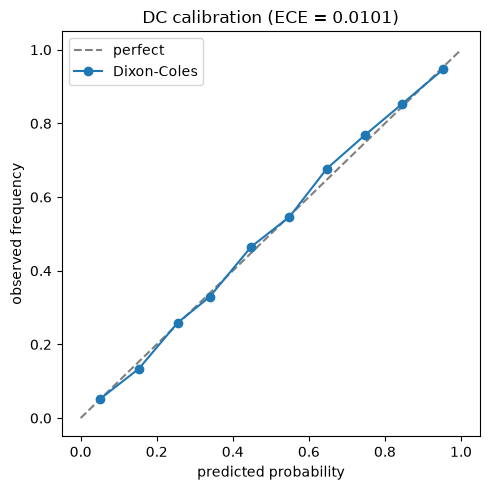

In [9]:
p_flat = P_dc.ravel()
o_flat = np.eye(3)[out].ravel()
bins = np.linspace(0, 1, 11)
b_idx = np.clip(np.digitize(p_flat, bins) - 1, 0, 9)
xs, ys = [], []
for b in range(10):
    m = b_idx == b
    if m.any():
        xs.append(p_flat[m].mean()); ys.append(o_flat[m].mean())

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0,1],[0,1], "--", color="grey", label="perfect")
ax.plot(xs, ys, "o-", label="Dixon-Coles")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title(f"DC calibration (ECE = {ece(P_dc, out):.4f})")
ax.legend(); plt.tight_layout(); plt.show()

---
## Hybrid: DC-into-XGBoost

Two XGBoost regressors (`objective="count:poisson"`) predict home & away expected goals from the `03_features` vector, with Dixon-Coles ratings included as the strength backbone. Rebuild the scoreline matrix from `(λ̂, μ̂)` and run it through the same walk-forward harness.

In [10]:
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from scipy.stats import poisson

feats = pd.read_parquet("../data/processed/features.parquet")
feats["neutral_int"] = feats["neutral"].astype(int)
feats_year = feats["date"].dt.year

KEYS = {"date","home_team","away_team","tournament","neutral","home_score","away_score"}
FEATURES = [c for c in feats.columns if c not in KEYS and c != "neutral_int"] + ["neutral_int"]

# feature groups (for the ablation later)
GROUPS = {
    "dc":      ["att_home","dfn_home","att_away","dfn_away","dc_lam","dc_mu","dc_ph","dc_pd","dc_pa"],
    "elo":     ["elo_home","elo_away","elo_diff"],
    "form":    ["f5_gf_home","f5_ga_home","f5_ppg_home","f5_gf_away","f5_ga_away","f5_ppg_away","f10_ppg_home","f10_ppg_away"],
    "rest":    ["rest_home","rest_away","rest_diff"],
    "venue":   ["is_home_home","is_home_away"],
    "context": ["competitiveness","h2h_n","h2h_gd","h2h_winrate","neutral_int"],
    "squad":   ["sv_home","sv_away","sv_diff"],
}
print(len(FEATURES), "features:", FEATURES)

33 features: ['att_home', 'dfn_home', 'att_away', 'dfn_away', 'dc_lam', 'dc_mu', 'dc_ph', 'dc_pd', 'dc_pa', 'elo_home', 'elo_away', 'elo_diff', 'f5_gf_home', 'f5_ga_home', 'f5_ppg_home', 'f5_gf_away', 'f5_ga_away', 'f5_ppg_away', 'f10_ppg_home', 'f10_ppg_away', 'rest_home', 'rest_away', 'rest_diff', 'is_home_home', 'is_home_away', 'competitiveness', 'h2h_n', 'h2h_gd', 'h2h_winrate', 'sv_home', 'sv_away', 'sv_diff', 'neutral_int']


In [11]:
gi = np.arange(11)

def train_poisson(Xtr, ytr, Xval, yval):
    m = xgb.XGBRegressor(
        objective="count:poisson", max_depth=3, learning_rate=0.05, n_estimators=2000,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
        early_stopping_rounds=40, eval_metric="poisson-nloglik", n_jobs=-1, verbosity=0)
    m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
    return m

def scoreline_probs(lam, mu, rho=0.0):
    lam = max(float(lam), 1e-6); mu = max(float(mu), 1e-6)
    mat = np.outer(poisson.pmf(gi, lam), poisson.pmf(gi, mu))   # independent Poisson (rho=0)
    if rho:
        mat[0,0]*=1-lam*mu*rho; mat[0,1]*=1+lam*rho; mat[1,0]*=1+mu*rho; mat[1,1]*=1-rho
    mat /= mat.sum()
    return np.array([np.tril(mat,-1).sum(), np.trace(mat), np.triu(mat,1).sum()])

## Walk-forward: DC vs XGB hybrid

Same folds for both models. Only matches whose teams DC has seen are scored, so both cover the identical set.

In [12]:
rows = []
for T in TEST_YEARS:
    tr = feats[feats_year < T]; te = feats[feats_year == T]
    if len(tr) < 500 or len(te) == 0:
        continue
    mdc = fit_dc(df[df["date"].dt.year < T]); known = set(mdc["idx"])
    cut = tr["date"].quantile(0.85)                      # last 15% (by time) = validation
    trn, val = tr[tr["date"] <= cut], tr[tr["date"] > cut]
    mh = train_poisson(trn[FEATURES], trn["home_score"], val[FEATURES], val["home_score"])
    ma = train_poisson(trn[FEATURES], trn["away_score"], val[FEATURES], val["away_score"])

    # --- fit Dirichlet calibrator on the validation slice (raw probs -> outcome) ---
    vlam, vmu = mh.predict(val[FEATURES]), ma.predict(val[FEATURES])
    Pval = np.array([scoreline_probs(vlam[k], vmu[k]) for k in range(len(val))])
    yval = np.array([outcome_index(h, a) for h, a in zip(val["home_score"], val["away_score"])])
    cal = LogisticRegression(max_iter=2000, C=1.0)
    cal.fit(np.log(np.clip(Pval, 1e-6, 1)), yval)
    cls = list(cal.classes_)

    # --- predict test: raw + calibrated ---
    lam, mu = mh.predict(te[FEATURES]), ma.predict(te[FEATURES])
    te_reset = te.reset_index(drop=True)
    Praw = np.array([scoreline_probs(lam[j], mu[j]) for j in range(len(te_reset))])
    Pcal = cal.predict_proba(np.log(np.clip(Praw, 1e-6, 1)))
    for j, r in te_reset.iterrows():
        if r["home_team"] not in known or r["away_team"] not in known:
            continue
        dcp = dc_predict_proba(mdc, r["home_team"], r["away_team"], bool(r["neutral"]))
        gbp = Praw[j]
        gcp = np.array([Pcal[j, cls.index(c)] for c in (0,1,2)])
        oc = outcome_index(r["home_score"], r["away_score"])
        rows.append({"year":T, "outcome":oc,
                     "dc_h":dcp[0],"dc_d":dcp[1],"dc_a":dcp[2],
                     "gb_h":gbp[0],"gb_d":gbp[1],"gb_a":gbp[2],
                     "gbc_h":gcp[0],"gbc_d":gcp[1],"gbc_a":gcp[2]})
    print(f"year {T}: trained + calibrated, evaluated {sum(1 for x in rows if x['year']==T)} matches")

pred2 = pd.DataFrame(rows)
print("\nTotal evaluated:", len(pred2))

year 2014: trained + calibrated, evaluated 810 matches


year 2015: trained + calibrated, evaluated 982 matches


year 2016: trained + calibrated, evaluated 875 matches


year 2017: trained + calibrated, evaluated 865 matches


year 2018: trained + calibrated, evaluated 870 matches


...

year 2021: trained + calibrated, evaluated 1115 matches


year 2022: trained + calibrated, evaluated 958 matches


year 2023: trained + calibrated, evaluated 998 matches


year 2024: trained + calibrated, evaluated 1221 matches


year 2025: trained + calibrated, evaluated 982 matches

Total evaluated: 11107


In [13]:
scorecard2 = pd.DataFrame({
    "Dixon-Coles":      score_block(pred2, "dc_h","dc_d","dc_a"),
    "XGB hybrid (raw)": score_block(pred2, "gb_h","gb_d","gb_a"),
    "XGB hybrid (cal)": score_block(pred2, "gbc_h","gbc_d","gbc_a"),
}).T
print("Out-of-sample, same", len(pred2), "matches:")
scorecard2.round(4)

Out-of-sample, same 11107 matches:


,RPS,LogLoss,Brier,ECE
Dixon-Coles,0.1701,0.8711,0.5121,0.0101
XGB hybrid (raw),0.1674,0.8625,0.5066,0.0102
XGB hybrid (cal),0.1678,0.8637,0.5073,0.0096


In [14]:
P_dc = pred2[["dc_h","dc_d","dc_a"]].to_numpy(); P_gb = pred2[["gb_h","gb_d","gb_a"]].to_numpy()
out = pred2["outcome"].to_numpy()
pred2["rps_dc"] = [rps(P_dc[i], out[i]) for i in range(len(pred2))]
pred2["rps_gb"] = [rps(P_gb[i], out[i]) for i in range(len(pred2))]
by_year2 = pred2.groupby("year")[["rps_dc","rps_gb"]].mean()
by_year2["lift_%"] = (1 - by_year2["rps_gb"] / by_year2["rps_dc"]) * 100
by_year2.round(4)

,rps_dc,rps_gb,lift_%
year,,,
2014,0.1831,0.1785,2.5029
2015,0.1739,0.1719,1.1318
2016,0.1679,0.1637,2.5437
2017,0.1778,0.1747,1.7612
2018,0.1780,0.1757,1.3287
2019,0.1640,0.1611,1.7746
2020,0.1916,0.1890,1.3798
2021,0.1483,0.1467,1.0573
2022,0.1822,0.1776,2.5226


## Feature importance (gain)

Fit both regressors and report which features drive the predictions.

In [15]:
cutF = feats["date"].quantile(0.9)
trnF, valF = feats[feats["date"] <= cutF], feats[feats["date"] > cutF]
mh_full = train_poisson(trnF[FEATURES], trnF["home_score"], valF[FEATURES], valF["home_score"])
ma_full = train_poisson(trnF[FEATURES], trnF["away_score"], valF[FEATURES], valF["away_score"])

def gain(m):
    return pd.Series(m.get_booster().get_score(importance_type="gain"))
imp = pd.DataFrame({"home_model": gain(mh_full), "away_model": gain(ma_full)}).fillna(0)
imp["avg"] = imp.mean(axis=1)
print("Top 15 features by gain (averaged over the two models):")
imp.sort_values("avg", ascending=False).head(15).round(2)

Top 15 features by gain (averaged over the two models):


,home_model,away_model,avg
dc_pa,101.71,187.69,144.70
dc_ph,173.31,60.05,116.68
dc_lam,66.66,9.15,37.90
dc_mu,8.41,65.91,37.16
dc_pd,40.64,26.58,33.61
elo_diff,15.93,19.39,17.66
sv_diff,10.40,15.71,13.05
f5_ga_home,4.84,13.92,9.38
f5_ga_away,12.80,4.99,8.90
sv_away,6.93,9.16,8.04


## Ablation

Drop one feature group at a time (last 4 folds). Positive ΔRPS means the group helps.

In [16]:
def run_gbm_wf(feature_cols, test_years):
    losses = []
    for T in test_years:
        tr = feats[feats_year < T]; te = feats[feats_year == T]
        if len(tr) < 500 or len(te) == 0:
            continue
        cut = tr["date"].quantile(0.85)
        trn, val = tr[tr["date"] <= cut], tr[tr["date"] > cut]
        mh = train_poisson(trn[feature_cols], trn["home_score"], val[feature_cols], val["home_score"])
        ma = train_poisson(trn[feature_cols], trn["away_score"], val[feature_cols], val["away_score"])
        lam = mh.predict(te[feature_cols]); mu = ma.predict(te[feature_cols])
        oc = [outcome_index(h,a) for h,a in zip(te["home_score"], te["away_score"])]
        for j in range(len(te)):
            losses.append(rps(scoreline_probs(lam[j], mu[j]), oc[j]))
    return float(np.mean(losses))

ABL_YEARS = [2022, 2023, 2024, 2025]
full_rps = run_gbm_wf(FEATURES, ABL_YEARS)
abl = {"FULL (all features)": full_rps}
for g, cols in GROUPS.items():
    keep = [c for c in FEATURES if c not in cols]
    abl[f"drop {g}"] = run_gbm_wf(keep, ABL_YEARS)

abl_df = pd.DataFrame({"RPS": abl})
abl_df["ΔRPS vs full"] = abl_df["RPS"] - full_rps   # >0 means the dropped group was helping
abl_df.round(5)

,RPS,ΔRPS vs full
FULL (all features),0.16723,0.00000
drop dc,0.17195,0.00473
drop elo,0.16748,0.00025
drop form,0.16761,0.00039
drop rest,0.16756,0.00033
drop venue,0.16735,0.00013
drop context,0.16754,0.00032
drop squad,0.16767,0.00044


## Calibration: DC vs XGB hybrid

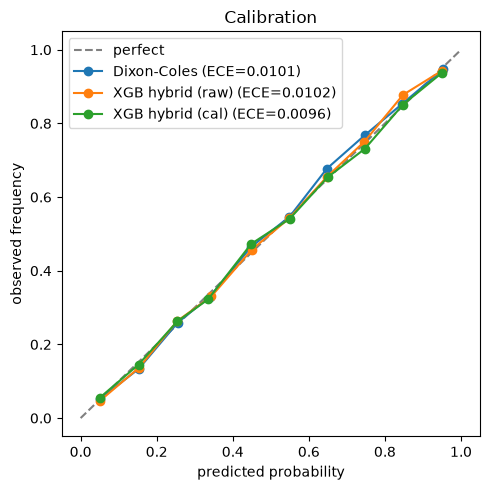

In [17]:
fig, ax = plt.subplots(figsize=(5,5))
ax.plot([0,1],[0,1],"--",color="grey",label="perfect")
P_gbc = pred2[["gbc_h","gbc_d","gbc_a"]].to_numpy()
for P, name in [(P_dc,"Dixon-Coles"), (P_gb,"XGB hybrid (raw)"), (P_gbc,"XGB hybrid (cal)")]:
    p = P.ravel(); o = np.eye(3)[out].ravel()
    bins = np.linspace(0,1,11); bidx = np.clip(np.digitize(p,bins)-1,0,9)
    xs = [p[bidx==b].mean() for b in range(10) if (bidx==b).any()]
    ys = [o[bidx==b].mean() for b in range(10) if (bidx==b).any()]
    ax.plot(xs, ys, "o-", label=f"{name} (ECE={ece(P,out):.4f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Calibration"); ax.legend(); plt.tight_layout(); plt.show()